# ML S1 · Notebook 02 — Build and Ship

## Machine Learning · Session 1 of 10

| | |
|---|---|
| **Session** | ML S1 — Foundations, and Shipping on Day One |
| **This notebook** | 03 of 3 (Build & Ship). Hands-on — you leave with a live app. |
| **Block types** | **Delivery** (AI assistance allowed and expected) |
| **Prerequisites** | Notebook 00 has been run (so `housing.csv` exists) · concepts from Notebook 01 |
| **Connects forward to** | ML S2 (baselines & metrics for this same model) · ML S9 (deployment, done properly) |
| **CEP link** | The repo + deploy workflow every certification submission uses |
| **Run requirements** | CPU only. Free GitHub account. Free Hugging Face **or** Streamlit Community Cloud account. |
| **Checkpoint** | `ML_S1_00_dataset.ipynb` must have produced `housing.csv` in this folder. |

---

### Learning objectives
By the end you will have:

1. Taken **raw data → a trained model → a deployed public web app** with its own URL.
2. Found and fixed the **planted data errors** from Notebook 00.
3. Scored the model honestly with a **train/test split and MAE**.
4. Put the project under **Git** and pushed it to GitHub.
5. Emitted a real **`app.py`** and **`requirements.txt`** from the notebook and deployed them.

> ### 🧭 This is a *delivery* block
> You may use an AI coding assistant here. That's realistic — it's how the job works in 2026. But the assessed skill is **direction and verification**: can you specify what you want, read what the assistant produced, and catch when it's wrong? Don't paste code you can't explain. We'll do plenty of *muscle* blocks (no AI) later to build the underlying intuition.


### Table of contents
1. [Ship it: from data to a live app](#s1)
   - Load & inspect · Clean the planted errors · Train · Score with MAE · Save the model · Emit `app.py` & `requirements.txt` · Run locally
2. [Git and the repo workflow](#s2)
3. [Deploy to a public URL](#s3)
4. [The lifecycle map & where your CEPs live](#s4)
5. [Common pitfalls · FAQ · Conclusion](#s5)


<a id="s1"></a>
## 1. Ship it: from data to a live app  ·  *~75 min*

We're going to move fast and end with something real. We are **not** trying to build the world's best model today — we're building a *complete pipeline* end to end, so you can see every piece. We deepen each piece in later sessions.

### Step 1 — Load and inspect


In [1]:
import pandas as pd

df = pd.read_csv("housing.csv")   # produced by ML_S1_00_dataset.ipynb
print("Rows, columns:", df.shape)
df.head()


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Rows, columns: (5000, 9)


,metro,location_tier,sqft,bedrooms,bathrooms,house_age,garage_spaces,lot_size,price
0,Phoenix,3,1186,3,1,37,1,2158,250900
1,Austin,2,1548,4,2,22,1,3074,497100
2,Columbus,3,2077,3,2,49,2,4723,429300
3,Chicago,2,1492,2,2,66,2,5467,376600
4,San Francisco,1,1719,2,2,25,2,6593,1466500


In [2]:
# Always look before you leap. Summary stats reveal a lot.
df.describe()


,location_tier,sqft,bedrooms,bathrooms,house_age,garage_spaces,lot_size,price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,1.930000,1919.538000,2.946400,1.839000,40.079600,1.350200,4944.588600,7.606434e+05
std,0.763424,836.133852,1.216151,0.792215,23.169226,0.847646,2342.904036,4.825196e+05
min,1.000000,500.000000,0.000000,1.000000,0.000000,0.000000,605.000000,8.160000e+04
25%,1.000000,1469.000000,2.000000,1.000000,20.000000,1.000000,3180.750000,3.931750e+05
50%,2.000000,1888.500000,3.000000,2.000000,40.000000,1.000000,4581.500000,6.256500e+05
75%,3.000000,2337.000000,4.000000,2.000000,61.000000,2.000000,6435.750000,1.008400e+06
max,3.000000,24620.000000,7.000000,5.000000,79.000000,3.000000,15749.000000,2.993900e+06


### Step 2 — Find and fix the planted errors

In Notebook 00 we deliberately planted two kinds of bad data. A professional *never* trusts clean-looking data — they check. Let's find them.


In [3]:
# Red flag 1: impossibly large houses. Look at the top of sqft.
print("Largest sqft values:")
print(df["sqft"].sort_values(ascending=False).head(8).to_string())
print()
# Red flag 2: impossible bedroom counts.
print("How many houses claim 0 bedrooms?", (df["bedrooms"] == 0).sum())


Largest sqft values:
691     24620
2901    20740
435     18830
1937    15490
12       9460
2529     5000
3212     4517
4168     4133

How many houses claim 0 bedrooms? 6


Two problems confirmed:
- A handful of houses with `sqft` in the tens of thousands — data-entry errors (a `1,800` typed as `18,000`).
- A few houses with `0` bedrooms — impossible.

**How to handle bad data** is a real judgment call (drop the rows? cap the values? investigate?). For today we'll keep it simple and defensible: **remove the clearly impossible rows.** It's a small fraction of the data and they're genuinely wrong.


In [4]:
before = len(df)

# Remove impossible bedrooms (0) and absurd sqft (> 10,000 is not a normal house here)
df = df[(df["bedrooms"] > 0) & (df["sqft"] <= 10_000)].copy()

after = len(df)
print(f"Removed {before - after} bad rows. {after} rows remain.")


Removed 10 bad rows. 4990 rows remain.


> ### 🌱 Just-in-Time — why we clean *before* modelling
> Garbage in, garbage out. A single house recorded as 18,000 sqft can distort what the model learns about how size relates to price. Cleaning isn't busywork — it's protecting the model from learning nonsense. (In ML S3 we'll see there's a *right* and *wrong* time to do some of this relative to the train/test split. For today's simple case, cleaning obvious errors up front is fine.)


### Step 3 — Choose features and target, then split

We frame it exactly as in Notebook 01: **target** = `price`, **unit** = one house. For today we use the numeric features (we'll bring the `metro` text column in properly in ML S2, when we learn encoding).


In [5]:
from sklearn.model_selection import train_test_split

feature_cols = ["sqft", "bedrooms", "bathrooms", "house_age",
                "garage_spaces", "lot_size", "location_tier"]

X = df[feature_cols]
y = df["price"]

# Hold out 20% as a test set the model never sees during training.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training houses:", len(X_train))
print("Test houses:    ", len(X_test))


Training houses: 3992
Test houses:     998


### Step 4 — Train a model

One simple model. `LinearRegression` learns a weighted formula: price ≈ (weight × sqft) + (weight × bedrooms) + … We'll interpret those weights properly in ML S2. Today we just want it trained.


In [6]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained.")


Model trained.


### Step 5 — Score it honestly with MAE

Judge on the **test set** — data the model never saw — using **Mean Absolute Error**: on average, how many dollars off is it?


In [7]:
from sklearn.metrics import mean_absolute_error

predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)

print(f"Test MAE: ${mae:,.0f}")
print(f"(On a typical house, the model's price guess is about ${mae:,.0f} off.)")


Test MAE: $180,932
(On a typical house, the model's price guess is about $180,932 off.)


> ### 🔎 2026 Reality Check
> Is this MAE *good*? You genuinely can't say yet — good compared to **what**? That question ("compared to what?") is the whole of next session. Today we just want an honest number, not a verdict. Resist the urge to call a model good or bad before you've given it something to beat.


### Step 6 — Save the trained model

To use the model in an app, we save it to a file so the app can load it without retraining every time.


In [8]:
import joblib

joblib.dump(model, "model.pkl")
print("Saved model.pkl")


Saved model.pkl


### Step 7 — Emit the app files

Here is the key idea of shipping: **a notebook is not an app.** A deployed web app needs real files on disk — a Python script and a list of its dependencies. We'll *write those files straight from the notebook* using the `%%writefile` magic, so you can see and understand every line.

> ### 🌱 Just-in-Time — the notebook → script boundary
> Notebooks are brilliant for exploring. But a live service can't be "a notebook someone ran" — it needs a program that starts up, loads the model, and responds to users. Learning to cross that boundary — from exploratory notebook to deployable script — is one of the most valuable and most-skipped skills. We're crossing it now, on purpose, on the simplest possible app.

The app below uses **Streamlit**, the easiest way to turn a Python script into a web app. The `%%writefile app.py` at the top means "don't run this cell — write its contents to a file called `app.py`."


In [1]:
%%writefile app.py

# app.py — a minimal Streamlit house-price predictor
import streamlit as st
import joblib
import numpy as np

# Load the model we trained and saved in the notebook.
model = joblib.load("model.pkl")

st.title("🏠 House Price Predictor")
st.write("Enter a house's details to estimate its price. (Demo model — trained on synthetic data.)")

# Input controls, one per feature, in the SAME order the model was trained on.
sqft          = st.number_input("Living area (sqft)", min_value=300, max_value=8000, value=1800)
bedrooms      = st.number_input("Bedrooms", min_value=1, max_value=7, value=3)
bathrooms     = st.number_input("Bathrooms", min_value=1, max_value=5, value=2)
house_age     = st.number_input("House age (years)", min_value=0, max_value=100, value=20)
garage_spaces = st.number_input("Garage spaces", min_value=0, max_value=3, value=1)
lot_size      = st.number_input("Lot size (sqft)", min_value=500, max_value=20000, value=4500)
location_tier = st.selectbox("Location tier (1 = priciest city, 3 = most affordable)", [1, 2, 3], index=1)

if st.button("Estimate price"):
    features = np.array([[sqft, bedrooms, bathrooms, house_age,
                          garage_spaces, lot_size, location_tier]])
    price = model.predict(features)[0]
    st.success(f"Estimated price: ${price:,.0f}")


Writing app/app.py


And the dependency list. When the app is deployed on a fresh server, this tells it what to install.

In [10]:
%%writefile requirements.txt
streamlit
scikit-learn
joblib
numpy


Writing requirements.txt


### Step 8 — Run it locally (optional, on your own machine)

On your own laptop you'd now open a terminal in this folder and run:

```bash
streamlit run app.py
```

That launches the app in your browser at `http://localhost:8501`. Play with the inputs and watch the price change.

*(In a shared classroom environment you may skip straight to deploying — the public URL works the same way, from anywhere.)*


> ### 🟢 Try It Yourself — add a feature to the form
> The app currently doesn't let the user pick a **metro** by name (we used `location_tier` instead). As a first taste of editing production code:
> 1. Change the `st.title` text to something of your own.
> 2. Change the default `value` of one of the inputs.
> 3. Re-run the `%%writefile app.py` cell to save your changes.
>
> Then check your edits landed:


In [11]:
# Verify your app.py changes were written:
print(open("app.py").read()[:400])


# app.py — a minimal Streamlit house-price predictor
import streamlit as st
import joblib
import numpy as np

# Load the model we trained and saved in the notebook.
model = joblib.load("model.pkl")

st.title("🏠 House Price Predictor")
st.write("Enter a house's details to estimate its price. (Demo model — trained on synthetic data.)")

# Input controls, one per feature, in the SAME order the model 


<details>
<summary><b>▶ Solution / what to notice</b></summary>

There's no single right answer — the point is the *loop*: edit the cell → re-run `%%writefile` → the file on disk updates → (later) redeploy. That edit-save-deploy loop is exactly how you'll iterate on every app in this course. If your `print` shows your new title, you did it right.
</details>


> ### ✅ Quick check
> 1. Why does a deployed app need `app.py` and `requirements.txt` as real files, when the notebook already "has" the model?
> 2. What does `train_test_split` protect you from?
> 3. What does the test MAE tell you that the training MAE would not?


<a id="s2"></a>
## 2. Git and the repo workflow  ·  *~30 min*

You now have three files that make up your project: `app.py`, `model.pkl`, and `requirements.txt`. To deploy them — and to be visible to employers — they need to live in a **Git repository** on GitHub.

### What Git is (without the mystique)
Git is a system of **save-points** for your project, plus a **shareable history**. Every "commit" is a snapshot you can return to. GitHub is the website that hosts your repo so others (and deployment platforms) can see it.

> ### 🌱 Just-in-Time — Git's three areas
> - **Working directory** — your files as they are right now.
> - **Staging area** — files you've *marked* to include in the next snapshot (`git add`).
> - **Commit** — the saved snapshot itself (`git commit`).
>
> The flow is always: edit → `add` (stage) → `commit` (save) → `push` (upload to GitHub).


### The workflow

Run these in a terminal, in your project folder. *(You run these on your own machine or the provided environment — they're shown here as reference; Git commands aren't run inside the notebook.)*

```bash
# One-time setup per project:
git init                       # start a repo here
git add app.py requirements.txt   # stage the code (NOT the data or model — see below)
git commit -m "Initial house-price app"   # save the first snapshot

# Connect to a GitHub repo you created (empty) on github.com:
git remote add origin https://github.com/YOUR-USERNAME/house-price-app.git
git branch -M main
git push -u origin main        # upload
```


### The `.gitignore` file — what NOT to commit

You don't commit everything. Data files and large model files usually stay out of Git (they bloat the repo and may be private). Create a file named `.gitignore`:


In [12]:
%%writefile .gitignore
# Data and models — don't commit these
housing.csv
*.pkl

# Python noise
__pycache__/
.ipynb_checkpoints/


Writing .gitignore


> ⚠️ **But wait — our app needs `model.pkl` to run!**
> True. For a tiny demo model like this, the simplest path is to **let the model file be committed** (comment out the `*.pkl` line above) so the deployment platform has it. For large models you'd use other storage — a topic for ML S9. For today: keep `housing.csv` ignored, but allow `model.pkl` so your app can load it. Adjust the `.gitignore` accordingly.

> ### 🔎 2026 Reality Check
> AI assistants write code faster than ever — which makes **version control more important, not less.** Git is how you keep control of code you (or an AI) changed: what changed, when, and how to undo it. And a clean public repo with sensible commit messages is a genuine hiring signal. "No repo" makes a candidate effectively invisible in the US and Indian markets.


> ### 🟢 Try It Yourself
> 1. Make a small change to `app.py` (e.g. tweak the title again).
> 2. Stage and commit it with a clear message: `git add app.py` then `git commit -m "Improve app title"`.
> 3. Push it: `git push`.
> 4. Refresh your repo page on GitHub — your change should be there, with your commit message in the history.

> ### ✅ Quick check
> 1. What does `.gitignore` protect you from?
> 2. What makes a *good* commit message? (Hint: think about someone reading the history six months later.)
> 3. In one line each: what do `add`, `commit`, and `push` do?


<a id="s3"></a>
## 3. Deploy to a public URL  ·  *(within the build)*

The final step: turn your repo into a live app anyone can visit. Two free options — pick one.

### Option A — Streamlit Community Cloud (easiest)
1. Go to **share.streamlit.io** and sign in with GitHub.
2. Click **"New app,"** pick your `house-price-app` repo, and set the main file to `app.py`.
3. Click **Deploy.** In a minute or two you get a public URL like `https://your-app.streamlit.app`.

### Option B — Hugging Face Spaces
1. Go to **huggingface.co/spaces** → **Create new Space**.
2. Choose **Streamlit** as the SDK.
3. Upload `app.py`, `requirements.txt`, and `model.pkl` (or connect your GitHub repo).
4. It builds and gives you a public URL like `https://huggingface.co/spaces/your-name/house-price-app`.

Either way, **you now have a live URL.** Send it to someone. That link is the first entry in your portfolio.

> ### ✅ Everyone's day-one outcome
> A public repo **and** a working live app URL. That is more than most people can show after a *month* of self-study — and you did it in session one.


<a id="s4"></a>
## 4. The lifecycle map & where your CEPs live  ·  *~15 min*

Step back and see what you just did. Every ML project moves through the same loop:

<div align="center">

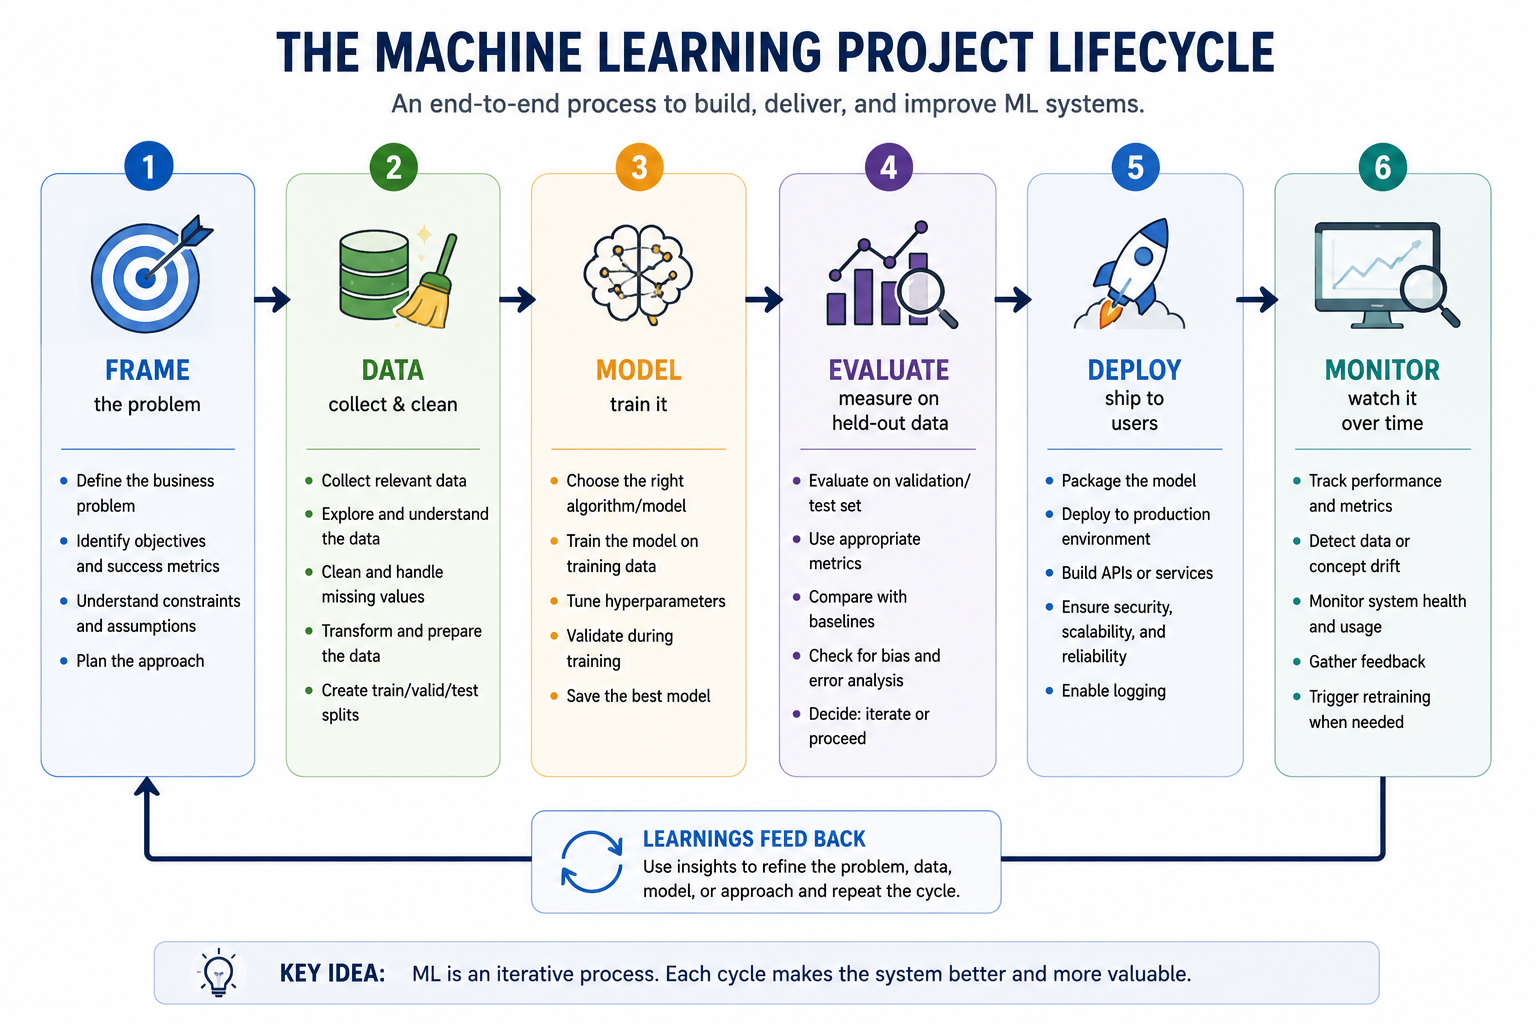

<p>
<b>Figure 1.</b> Machine Learning Project Lifecyle
</p>

</div>

**Today you went all the way around this loop** — shallowly, on purpose. You framed (house price), handled data (loaded, cleaned the planted errors), modelled (LinearRegression), evaluated (test MAE), and deployed (live URL). The next nine sessions each go *deep* on one stage.

### Where your certification projects sit

| Project | Course | Main lifecycle stages it stresses |
|---|---|---|
| **Employee Turnover** | ML | Frame · Data (imbalance) · Model · **Evaluate** (recall, ROC/AUC, risk bands) |
| **Cohorts of Songs** | ML | Data · Model (clustering) · Interpret |
| **Home Loan** | DL | Data (imbalance) · Model (neural) · Evaluate (sensitivity, AUC) |
| **Lending Club** | DL | Data · Feature selection · Model (Keras) · Evaluate |

Notice: three of the four are fundamentally **evaluation** problems on imbalanced data. That's why we make evaluation the backbone of the course — starting properly in ML S3.

> ### ✅ Quick check
> Look at any ML job description online. Which lifecycle stage(s) does it emphasise? (Many "ML Engineer" roles are heavy on **Deploy** and **Monitor** — the stages most self-taught learners skip, and the ones you just practised.)


<a id="s5"></a>
## 5. Wrap-up

### Common pitfalls
- **Deploy fails from a missing or wrong `requirements.txt`.** If the server can't install a library your app needs, it won't start. Keep this file honest.
- **Committing data or secrets.** Never push private data or API keys to a public repo. That's what `.gitignore` is for.
- **"It runs in my notebook" ≠ "it's deployed."** Local success and a live public URL are different milestones. Both matter.
- **Treating today's MAE as a final grade.** It's a first honest number, not a verdict — we have nothing to compare it to yet.
- **Feature order mismatch.** The app must feed features to the model in the *same order* they were trained. Get this wrong and predictions are silently garbage.

### FAQ
- **Do I have to pay for hosting?** No. Streamlit Community Cloud and Hugging Face Spaces both have free tiers that are plenty for this.
- **My `git push` was rejected — why?** Usually the remote already has commits, or you're not authenticated. Check the error text; it's almost always one of those two.
- **Why Streamlit and not Flask/FastAPI?** Streamlit turns a Python script into a web UI with the least ceremony — ideal for getting a model in front of people fast. Heavier frameworks come later if you need them.
- **Can I let an AI assistant write all of this?** For this delivery block, yes — but you must be able to *explain and verify* every line. That's the actual skill.
- **Do I have to redo this if I miss ML S2?** No. S2 uses a fresh checkpoint; you won't be stranded.

### Conclusion
You shipped a live app on day one: raw data → cleaned → trained → honestly scored → version-controlled → deployed to a public URL. It's deliberately shallow — every stage gets deepened in the sessions ahead. But the shape of real ML work is now something you've *done*, not just read about.

### ➡️ Transition to ML S2
Your model is "off by about \$X on a typical house." Is that good? You have nothing to compare it against yet. **Next session opens with the missing piece: a *baseline* your model must beat — and the proper metrics (RMSE, R², and friends) to judge it.** We'll also learn *regularization*, an idea that comes back verbatim in the Deep Learning course. See you there.
